# Multi-Subreddit Dataset and Engagement Model

Following the single-subreddit analysis, this notebook expands the dataset to include multiple subreddits in order to introduce variation in topic, tone, and safety.

🎯 **Goal**: Build a combined dataset and test whether adding variation improves the ability to predict engagement from titles.

**Approach**:

- Combine multiple subreddit datasets into a single dataframe  
- Define a consistent engagement metric and binary label  
- Train a baseline model using titles only  

### ⭐️ Executive Summary

This notebook expands the dataset from a single subreddit to a multi-subreddit sample in order to introduce variation in topic, tone, and safety, and test whether this improves the ability to predict engagement from titles.

Moving to a multi-subreddit dataset introduces meaningful signal. A baseline model using title text alone is now able to identify some high-engagement posts, where the single-subreddit model failed entirely.

A series of experiments were then run to test different ways of improving performance, including adding contextual features, simple structural features, class weighting, and a more flexible model (XGBoost).

The most significant improvement comes from introducing **subreddit as a contextual feature** and applying **class weighting**, which substantially increases recall for high-engagement posts. In contrast, simple structural features (e.g. title length, punctuation) and model complexity (XGBoost) do not provide additional value.

These results suggest that performance is primarily driven by **context (in which subreddit the content is posted)**, while **title-based signal remains limited under TF-IDF**. This motivates a shift in focus towards improving text representation.

As a result, embedding-based approaches are explored in a separate notebook to better capture semantic meaning in titles.

---

### 📊 Model Comparison

| Model | Features | Class Weighting | Recall (High) | Precision (High) | Notes |
|------|----------|----------------|----------------|------------------|------|
| TF-IDF Baseline | Title | ❌ | 0.38 | 0.77 | Weak signal from text alone |
| Contextual Model | Title + Subreddit | ❌ | 0.54 | 0.77 | Large gain from context |
| Structure Model | Title + Structure | ❌ | 0.23 | 0.65 | Structural features ineffective |
| Context + Structure | Title + Subreddit + Structure | ❌ | 0.53 | 0.77 | No additional benefit |
| Context + Weighting | Title + Subreddit | ✅ | **0.83** | 0.60 | Best performing model (recall-focused) |
| Context + Structure + Weighting | + Post Type | ✅ | 0.83 | 0.60 | No meaningful change |
| XGBoost Contextual | Title + Subreddit | ✅ | 0.83 | 0.56 | More complex model, no gain |



### Key Takeaways

- Expanding the dataset introduces meaningful signal for modelling engagement  
- Subreddit (context) is the strongest predictor of performance  
- Simple structural features do not meaningfully improve results  
- Class weighting is effective for improving recall of high-engagement posts  
- Increasing model complexity (XGBoost) does not improve performance  

👉 Overall, results indicate that **feature quality — particularly contextual information — matters more than model choice at this stage**, and that improving text representation is the most promising next step.

### Imports

In [ ]:
import duckdb
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

## Create single multi subreddit dataset

In [2]:
# --- Load subreddit data ---

# Select all rows from all subreddit csv to create df - and skip 50_subreddits_list
df = duckdb.query("""
    SELECT *
    FROM read_csv_auto('../data/[a-z]*.csv', filename=True)
""").to_df()

df.shape

(49266, 20)

In [3]:
# Confirm new filename has been added
df["filename"].head()

0    ../data/anime.csv
1    ../data/anime.csv
2    ../data/anime.csv
3    ../data/anime.csv
4    ../data/anime.csv
Name: filename, dtype: str

In [4]:
# Add subreddit name: Take last part of file path
df["subreddit"] = df["filename"].str.split("/").str[-1]

# Remove .csv
df["subreddit"] = df["subreddit"].str.replace(".csv", "", regex=False)

# Check
df[["filename", "subreddit"]].head()

,filename,subreddit
0,../data/anime.csv,anime
1,../data/anime.csv,anime
2,../data/anime.csv,anime
3,../data/anime.csv,anime
4,../data/anime.csv,anime


In [5]:
# --- Filter df to match shortlist ---

# Redefine shortlist of subreddits - lower case to match filenames
shortlist = ["aww","todayilearned","gaming","nostupidquestions","creepy","askreddit","tifu"]

# Create df with all shortlist subreddits combined
shortlist_combined_df = df[df["subreddit"].isin(shortlist)].copy()

shortlist_combined_df.shape

(6936, 20)

In [6]:
shortlist_combined_df["subreddit"].value_counts()

subreddit
creepy               997
gaming               996
tifu                 994
aww                  993
askreddit            987
nostupidquestions    986
todayilearned        983
Name: count, dtype: int64

## Recreate Engagement measures

In [7]:
# Create and scale engagement measure to standardise score and comments
scaler = StandardScaler()

shortlist_combined_df[["score_scaled", "comments_scaled"]] = scaler.fit_transform(
    shortlist_combined_df[["score", "num_comments"]]
)

shortlist_combined_df["engagement"] = shortlist_combined_df["score_scaled"] + shortlist_combined_df["comments_scaled"]

shortlist_combined_df.columns.tolist()

['id',
 'title',
 'score',
 'upvote_ratio',
 'num_comments',
 'created_utc',
 'subreddit',
 'subscribers',
 'permalink',
 'url',
 'domain',
 'num_awards',
 'num_crossposts',
 'crosspost_subreddits',
 'post_type',
 'is_nsfw',
 'is_bot',
 'is_megathread',
 'body',
 'filename',
 'score_scaled',
 'comments_scaled',
 'engagement']

In [8]:
# --- Recreate binary label for high engagement ---

# Reuse initial threshold as 75th percentile
threshold = shortlist_combined_df["engagement"].quantile(0.75)

shortlist_combined_df["high_engagement"] = (shortlist_combined_df["engagement"] >- threshold).astype(int)

# Check: Distribution should be ~75% high engagement
shortlist_combined_df["high_engagement"].value_counts(normalize=True)

high_engagement
1    0.617359
0    0.382641
Name: proportion, dtype: float64

In [9]:
# Inspect engagement distribution
shortlist_combined_df["engagement"].describe()

count    6936.000000
mean        0.000000
std         1.461342
min        -1.901320
25%        -1.306785
50%         0.123388
75%         0.744719
max         9.351919
Name: engagement, dtype: float64

<Axes: >

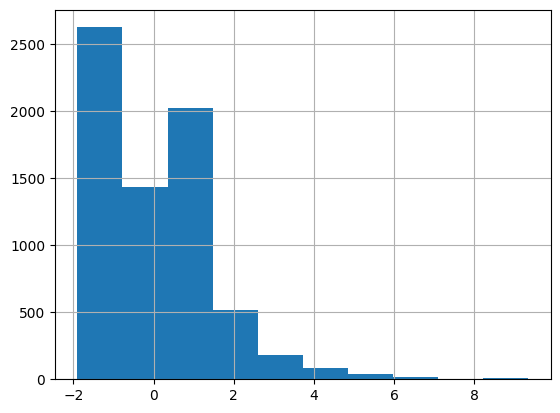

In [10]:
shortlist_combined_df["engagement"].hist()

In [11]:
# Check initial threshold assumption (75th percentile and above)
threshold = shortlist_combined_df["engagement"].quantile(0.75)
print(threshold)

0.7447187303777609


In [12]:
# Instead, define high engagement as top 25% scores
shortlist_combined_df["engagement_rank"] = (
    shortlist_combined_df["engagement"].rank(pct=True)
)

shortlist_combined_df["high_engagement"] = (
    shortlist_combined_df["engagement_rank"] >= 0.75
).astype(int)

# Check: Distribution should be ~75% high engagement
shortlist_combined_df["high_engagement"].value_counts(normalize=True)

high_engagement
0    0.749856
1    0.250144
Name: proportion, dtype: float64

☝️ Engagement is highly skewed, with a long tail of very high-performing posts. 

A rank-based threshold is used to define high engagement, ensuring a consistent top-quartile split across the dataset.

## Validating Performance Signal with multiple subreddits

In [13]:
# Define features and target for modelling
X = shortlist_combined_df["title"]
y = shortlist_combined_df["high_engagement"]

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert text data to numerical features using TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=5000)

# Learn vocab from training data / transform training and test data
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train a logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_vec, y_train)

# Predict on test set and evaluate
y_pred = model.predict(X_test_vec)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.96      0.89      1041
           1       0.77      0.38      0.51       347

    accuracy                           0.82      1388
   macro avg       0.80      0.67      0.70      1388
weighted avg       0.81      0.82      0.79      1388

[[1002   39]
 [ 215  132]]


### 🙋‍♀️ Dataset & Baseline Summary

To introduce more variation in content, posts from multiple subreddits were combined into a single dataset (~7k posts across 7 topics). This allows the model to see a broader range of tone and subject matter compared to the single-subreddit analysis.

##### Measuring Performance (Engagement)
Engagement was again defined using a combined score based on post score and comment count. However, when applying the same thresholding approach as before, the distribution of engagement scores proved highly skewed across subreddits, resulting in an unstable split.

To address this, the high-engagement label was instead defined using a rank-based approach, where the top 25% of posts are labelled as high engagement. This ensures a consistent and comparable target across a more varied dataset.

##### New Baseline
A baseline model was then trained using post titles as the only feature. Unlike the single-subreddit case (where recall for high-engagement posts was 0), the model is now able to identify some high-performing content, achieving a recall of 0.38 and precision of 0.77 for the high-engagement class.

This suggests that adding variation across subreddits introduces useful signal. However, the model still misses a large proportion of high-performing posts, indicating that title text alone is not sufficient.

## Improving the Model

So far, the model only uses title text. The next step is to introduce additional features and test whether they improve performance.

This will be explored in three steps:

- Add simple structured features (e.g. subreddit, title characteristics)  
- Assess whether additional data or feature refinement improves signal  
- Explore more flexible models if needed  

### Adding features

Rather than adding features arbitrarily, the next step is to test hypotheses about what might influence engagement.

**Hypothesis 1: Context influences engagement**  
Posts perform differently depending on where they are shared, reflecting differences in audience and norms across subreddits.  
→ If `subreddit` is added as a feature, the model should better distinguish high- and low-engagement posts.

**Hypothesis 2: Title structure influences engagement**  
The way a title is written — for example, whether it is a question, a short reaction, or more descriptive — affects how users respond.  
→ If simple structural features (`title_length`, `has_question`, `has_number`) are added, the model should improve its ability to identify high-engagement posts.

#### H1: Context influences engagement

In [14]:
# Add subreddit to the feature set
X_context = shortlist_combined_df[["title", "subreddit"]]
y = shortlist_combined_df["high_engagement"]

# Splits
X_context_train, X_context_test, y_train, y_test = train_test_split(
    X_context,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Define preprocessing pipeline for text and subreddit features
context_preprocessor = ColumnTransformer(
    transformers=[
        ("title_tfidf", TfidfVectorizer(stop_words='english', max_features=5000), "title"),
        ("subreddit_ohe", OneHotEncoder(handle_unknown="ignore"), ["subreddit"])
    ]
)

# Create full pipeline with preprocessing and logistic regression
context_pipeline = Pipeline([
    ("preprocessor", context_preprocessor),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])

# Fit the pipeline on the training data
context_pipeline.fit(X_context_train, y_train)

# Predict on the test set
y_context_pred = context_pipeline.predict(X_context_test)

# Evaluate the model
print("Classification Report: H1 Contextual Model")
print(classification_report(y_test, y_context_pred))
print(confusion_matrix(y_test, y_context_pred))


Classification Report: H1 Contextual Model
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      1041
           1       0.77      0.54      0.64       347

    accuracy                           0.84      1388
   macro avg       0.81      0.74      0.77      1388
weighted avg       0.84      0.84      0.83      1388

[[984  57]
 [159 188]]


#### H2: Title structure influences engagement

In [15]:
# --- Create title structure features ---

# Title length
shortlist_combined_df["title_length"] = shortlist_combined_df["title"].str.len()

# Has question mark
shortlist_combined_df["has_question"] = shortlist_combined_df["title"].str.contains(r'\?').astype(int)

# Has exclamation mark
shortlist_combined_df["has_exclamation"] = shortlist_combined_df["title"].str.contains(r'!').astype(int)

# Has number
shortlist_combined_df["has_number"] = shortlist_combined_df["title"].str.contains(r'\d').astype(int)

# Check new features
shortlist_combined_df[["title", "title_length", "has_question", "has_exclamation", "has_number"]].head(5)

,title,title_length,has_question,has_exclamation,has_number
1953,"People who haven't pooped in 2019 yet, why are...",87,1,0,1
1954,How would you feel about Reddit adding 3 NSFW ...,208,1,0,1
1955,Would you watch a show where a billionaire CEO...,208,1,0,0
1956,"What if God came down one day and said ""It's p...",72,1,0,0
1957,How would you feel about a feature where if so...,116,1,0,0


In [16]:
# Add structure features to the feature set
X_structure = shortlist_combined_df[["title", "title_length", "has_question", "has_exclamation", "has_number"]]
y = shortlist_combined_df["high_engagement"]

# Splits
X_structure_train, X_structure_test, y_train, y_test = train_test_split(
    X_structure,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Define preprocessing pipeline for text and structure features
structure_preprocessor = ColumnTransformer(
    transformers=[
        ("title_tfidf", TfidfVectorizer(stop_words='english', max_features=5000), "title"),
        ("structure", "passthrough", ["title_length", "has_question", "has_exclamation", "has_number"])
    ]
)

# Create full pipeline with preprocessing and logistic regression
structure_pipeline = Pipeline([
    ("preprocessor", structure_preprocessor),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])

# Fit the pipeline on the training data
structure_pipeline.fit(X_structure_train, y_train)

# Predict on the test set
y_structure_pred = structure_pipeline.predict(X_structure_test)

# Evaluate the model
print("Classification Report: H2 Structure Model")
print(classification_report(y_test, y_structure_pred))
print(confusion_matrix(y_test, y_structure_pred))

Classification Report: H2 Structure Model
              precision    recall  f1-score   support

           0       0.79      0.96      0.87      1041
           1       0.65      0.23      0.34       347

    accuracy                           0.78      1388
   macro avg       0.72      0.60      0.60      1388
weighted avg       0.75      0.78      0.73      1388

[[997  44]
 [266  81]]


In [17]:
# --- Combine context and structure features ---
X_combined = shortlist_combined_df[["title", "subreddit", "title_length", "has_question", "has_exclamation", "has_number"]]
y = shortlist_combined_df["high_engagement"]

# Splits
X_combined_train, X_combined_test, y_train, y_test = train_test_split(
    X_combined,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Define preprocessing pipeline for combined features
combined_preprocessor = ColumnTransformer(
    transformers=[
        ("title_tfidf", TfidfVectorizer(stop_words='english', max_features=5000), "title"),
        ("subreddit_ohe", OneHotEncoder(handle_unknown="ignore"), ["subreddit"]),
        ("structure", "passthrough", ["title_length", "has_question", "has_exclamation", "has_number"])
    ]
)

# Create full pipeline with preprocessing and logistic regression
combined_pipeline = Pipeline([
    ("preprocessor", combined_preprocessor),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])

# Fit the pipeline on the training data
combined_pipeline.fit(X_combined_train, y_train)

# Predict on the test set
y_combined_pred = combined_pipeline.predict(X_combined_test)

# Evaluate the model
print("Classification Report: Contextual + Structure Model")
print(classification_report(y_test, y_combined_pred))
print(confusion_matrix(y_test, y_combined_pred))

Classification Report: Contextual + Structure Model
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      1041
           1       0.77      0.53      0.63       347

    accuracy                           0.84      1388
   macro avg       0.81      0.74      0.77      1388
weighted avg       0.84      0.84      0.83      1388

[[986  55]
 [162 185]]


#### 🙋‍♀️ Context vs Structure Features

Adding subreddit as a feature leads to a clear improvement in performance, particularly in recall for high-engagement posts (0.38 → 0.54). This suggests that context plays a significant role in how content performs.

In contrast, simple structural features (e.g. title length, presence of questions or numbers) do not improve performance when used alone, and add little when combined with subreddit. This indicates that these features are too coarse to capture meaningful differences in engagement.

👉 Overall, **performance appears to be driven more by context than by basic title structure**.

### Optimise text feature

Hypothesis: Phrase-level patterns in titles (e.g. “why do”, “TIFU by”) provide stronger signal than individual words, and will improve model performance.

In [18]:
# --- Rerun contextual model with bigrams ---

# Update TF-IDF vectorizer to include bigrams
context_preprocessor_bigram = ColumnTransformer(
    transformers=[
        ("title_tfidf", TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1,2)), "title"),
        ("subreddit_ohe", OneHotEncoder(handle_unknown="ignore"), ["subreddit"])
    ]
)

# Create full pipeline with bigram TF-IDF and logistic regression
context_pipeline_bigram = Pipeline([
    ("preprocessor", context_preprocessor_bigram),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])

# Fit the pipeline on the training data
context_pipeline_bigram.fit(X_context_train, y_train)

# Predict on the test set
y_context_bigram_pred = context_pipeline_bigram.predict(X_context_test)

# Evaluate the model
print("Classification Report: Contextual Model with Bigrams")
print(classification_report(y_test, y_context_bigram_pred))
print(confusion_matrix(y_test, y_context_bigram_pred))

Classification Report: Contextual Model with Bigrams
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      1041
           1       0.76      0.53      0.62       347

    accuracy                           0.84      1388
   macro avg       0.81      0.74      0.76      1388
weighted avg       0.83      0.84      0.83      1388

[[981  60]
 [162 185]]


👉 **Introducing bigrams to capture phase-level patterns does not lead to a meaningful improvement in performance.**

This suggests that much of the signal captured by these phrases is already explained by subreddit context, and that further gains are unlikely from simple extensions of the TF-IDF approach.

**What's next?**

The confusion matrix shows that the model is still missing a large number of high-engagement posts (false negatives), indicating a bias towards predicting the majority class. Introducing class weighting shifts the model’s focus towards the minority class, with the aim of improving recall for high-engagement content.

## Class weighting

**Hypothesis: Class weighting will improve recall for high-engagement posts**  
High-engagement posts are the minority class, so the model may be biased towards predicting low engagement.  
→ If class weighting is introduced, recall for high-engagement posts should improve, even if precision falls slightly.

In [19]:
# Include balanced class weights in logistic regression
context_pipeline_balanced = Pipeline([
    ("preprocessor", context_preprocessor),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced"))
])

# Fit the pipeline on the training data
context_pipeline_balanced.fit(X_context_train, y_train)

# Predict on the test set
y_context_balanced_pred = context_pipeline_balanced.predict(X_context_test)

# Evaluate the model
print("Classification Report: Contextual Model with Balanced Class Weights")
print(classification_report(y_test, y_context_balanced_pred))
print(confusion_matrix(y_test, y_context_balanced_pred))

Classification Report: Contextual Model with Balanced Class Weights
              precision    recall  f1-score   support

           0       0.94      0.82      0.87      1041
           1       0.60      0.83      0.70       347

    accuracy                           0.82      1388
   macro avg       0.77      0.82      0.78      1388
weighted avg       0.85      0.82      0.83      1388

[[849 192]
 [ 59 288]]


👉 **Introducing class weighting significantly improves recall for high-engagement posts** (0.54 → 0.83), reducing the number of missed high-performing posts from 159 to 59. 

This comes at the cost of precision, with more low-engagement posts incorrectly classified as high. This trade-off is expected, and highlights the importance of prioritising recall in scenarios where missing high-performing content is more costly than false positives.

*We’ve made the model more willing to take a chance on posts being “high-performing”. That means it now catches most of the good ones, but also includes a few that turn out not to be.*

### Post Type

Post Type *may* capture behaviour or context better than the raw title text alone, which in turn may affect engagement.

In [20]:
print(shortlist_combined_df["post_type"].unique())
print(shortlist_combined_df["post_type"].value_counts())

<ArrowStringArray>
['text', 'video', 'image', 'link']
Length: 4, dtype: str
post_type
text     2975
image    1789
link     1710
video     462
Name: count, dtype: int64


In [21]:
# --- Context feature set with post type and weighted logistic regression ---

# Add post type to the feature set
X_post_type = shortlist_combined_df[["title", "subreddit", "post_type"]]
y = shortlist_combined_df["high_engagement"]

# Splits
X_post_type_train, X_post_type_test, y_train, y_test = train_test_split(
    X_post_type,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Define preprocessing pipeline for combined features
post_type_preprocessor = ColumnTransformer(
    transformers=[
        ("title_tfidf", TfidfVectorizer(stop_words='english', max_features=5000), "title"),
        ("subreddit_ohe", OneHotEncoder(handle_unknown="ignore"), ["subreddit"]),
        ("post_type_ohe", OneHotEncoder(handle_unknown="ignore"), ["post_type"])
    ]
)

# Create full pipeline with preprocessing and logistic regression with balanced class weights
post_type_pipeline = Pipeline([
    ("preprocessor", post_type_preprocessor),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced"))
])

# Fit the pipeline on the training data
post_type_pipeline.fit(X_post_type_train, y_train)

# Predict on the test set
y_post_type_pred = post_type_pipeline.predict(X_post_type_test)

# Evaluate the model
print("Classification Report: Contextual Model with Post Type and Balanced Class Weights")
print(classification_report(y_test, y_post_type_pred))
print(confusion_matrix(y_test, y_post_type_pred))

Classification Report: Contextual Model with Post Type and Balanced Class Weights
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      1041
           1       0.60      0.83      0.69       347

    accuracy                           0.82      1388
   macro avg       0.77      0.82      0.78      1388
weighted avg       0.85      0.82      0.83      1388

[[849 192]
 [ 60 287]]


👉 **Adding post type as a feature does not lead to a meaningful improvement in performance**. 

This suggests that any signal captured by post type is already largely explained by subreddit context, and does not provide additional predictive value in this setup.

## XGBoost

Hypothesis: A more flexible model (XGBoost) will capture non-linear patterns in the data and improve performance over logistic regression.

In [22]:
# --- XGBoost with context features and balanced class weights ---

# Create full pipeline with preprocessing and XGBoost classifier
xgb_pipeline = Pipeline([
    ("preprocessor", context_preprocessor),
    # 75/25 class imbalance -> scale_pos_weight = 3
    ("classifier", XGBClassifier(random_state=42, scale_pos_weight=3))
])

# Fit the pipeline on the training data
xgb_pipeline.fit(X_context_train, y_train)

# Predict on the test set
y_xgb_pred = xgb_pipeline.predict(X_context_test)

# Evaluate the model
print("Classification Report: XGBoost Contextual Model")
print(classification_report(y_test, y_xgb_pred))
print(confusion_matrix(y_test, y_xgb_pred))

Classification Report: XGBoost Contextual Model
              precision    recall  f1-score   support

           0       0.93      0.78      0.85      1041
           1       0.56      0.83      0.67       347

    accuracy                           0.79      1388
   macro avg       0.74      0.80      0.76      1388
weighted avg       0.84      0.79      0.80      1388

[[813 228]
 [ 60 287]]


👉 **Switching from logistic regression to XGBoost does not improve performance**. Recall for high-engagement posts remains effectively unchanged, while precision falls and false positives increase.

This suggests that a more flexible model is not extracting additional useful signal from the current feature set. At this stage, feature quality appears to matter more than model complexity.

## Embeddings

Recent experiments suggest that performance is now more limited by feature quality than by model choice. Embeddings are a sensible next step because they represent the meaning of a title more effectively than TF-IDF, which may help recover signal that simple word and phrase matching misses.

⚠️ Embedding-based modelling was attempted, but importing the required transformer libraries destabilised the notebook kernel, so this experiment was deferred to a separate environment - see 04_embeddings.ipynb.

In [23]:
# Save df with new features for next notebook
shortlist_combined_df.to_parquet("../data/processed/shortlist_combined_df.parquet", index=False)

print("✅ Data with new features saved for next notebook.")

✅ Data with new features saved for next notebook.
